# Importing libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.pipeline import Pipeline


# Fetching the dataset

In [2]:
df = pd.read_csv('housing.csv') 
X = df.drop(df.columns[-2], axis=1).values
Y = df.iloc[:, -2].values
X

array([[-122.23, 37.88, 41.0, ..., 126.0, 8.3252, 'NEAR BAY'],
       [-122.22, 37.86, 21.0, ..., 1138.0, 8.3014, 'NEAR BAY'],
       [-122.24, 37.85, 52.0, ..., 177.0, 7.2574, 'NEAR BAY'],
       ...,
       [-121.24, 39.37, 16.0, ..., 530.0, 2.3886, 'INLAND'],
       [-121.53, 39.19, 27.0, ..., 382.0, 2.5495, 'INLAND'],
       [-121.43, 39.18, 36.0, ..., 171.0, 2.1667, 'INLAND']],
      shape=(20673, 9), dtype=object)

# Taking care of duplicated rows

In [3]:
nbr_duplicated = df.duplicated().sum()
print("Number of duplicated rows : ", nbr_duplicated)

Number of duplicated rows :  33


In [4]:
df = df.drop_duplicates()
nbr_duplicated = df.duplicated().sum()
print("Number of duplicated rows : ", nbr_duplicated)

Number of duplicated rows :  0


Detecting the missing values

In [5]:
missing_values = df.isna().sum()
print(missing_values)

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [6]:
missing_values = pd.DataFrame(X).isna().sum()
print(missing_values)

0      0
1      0
2      0
3      0
4    207
5      0
6      0
7      0
8      0
dtype: int64


# Taking care of missing data

In [7]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X[:, 4] = imputer.fit_transform(X[:, 4].reshape(-1, 1)).flatten()

Verifiying if the missing values are correctly handled

In [8]:
missing_values = pd.DataFrame(X).isna().sum()
print(missing_values)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64


# Statistics analyse : 

## Detecting outliers features

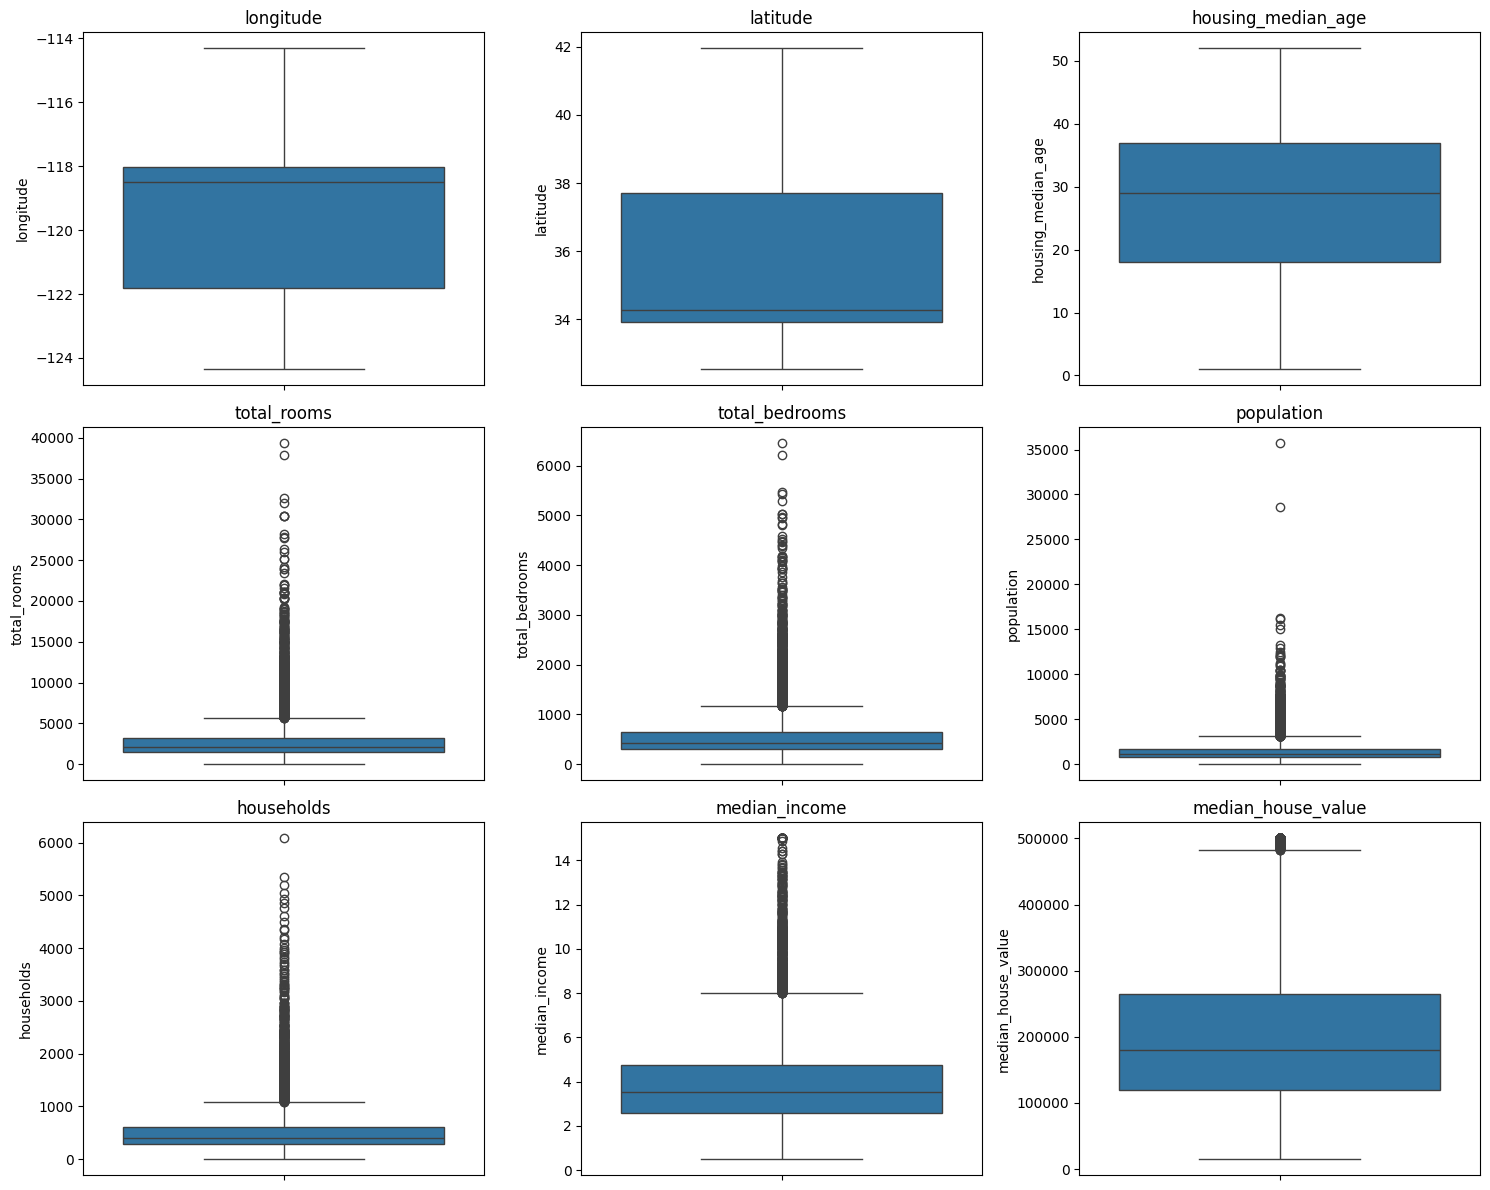

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

df_numeric = df.select_dtypes(include=["number"])

num_cols = len(df_numeric.columns)

rows = math.ceil(num_cols / 3)  
cols = min(3, num_cols)  

plt.figure(figsize=(cols * 5, rows * 4))

for i, col in enumerate(df_numeric.columns, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y=df_numeric[col])
    plt.title(col)

plt.tight_layout()
plt.show()


##### After Analyzing all those graphes, we are obliged to transform our values to values who follow the same scale

## Mean, std analyse 

In [10]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Feature importance using heatmap

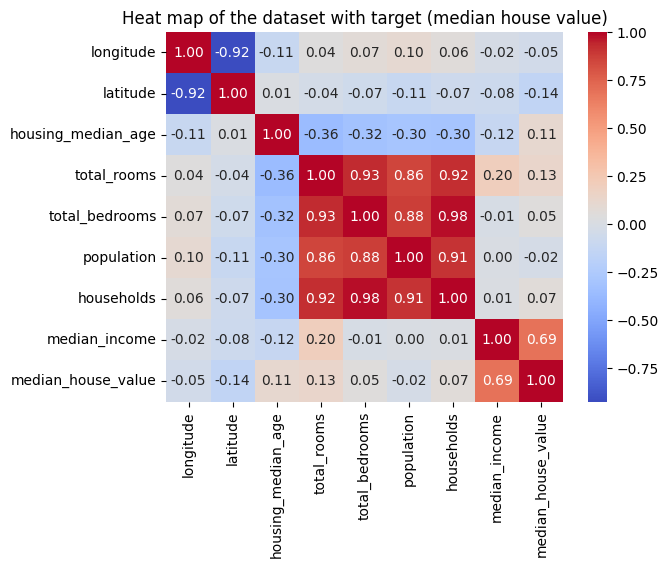

In [11]:
corr_matrix = df.select_dtypes(include=["number"]).corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heat map of the dataset with target (median house value)")
plt.show()

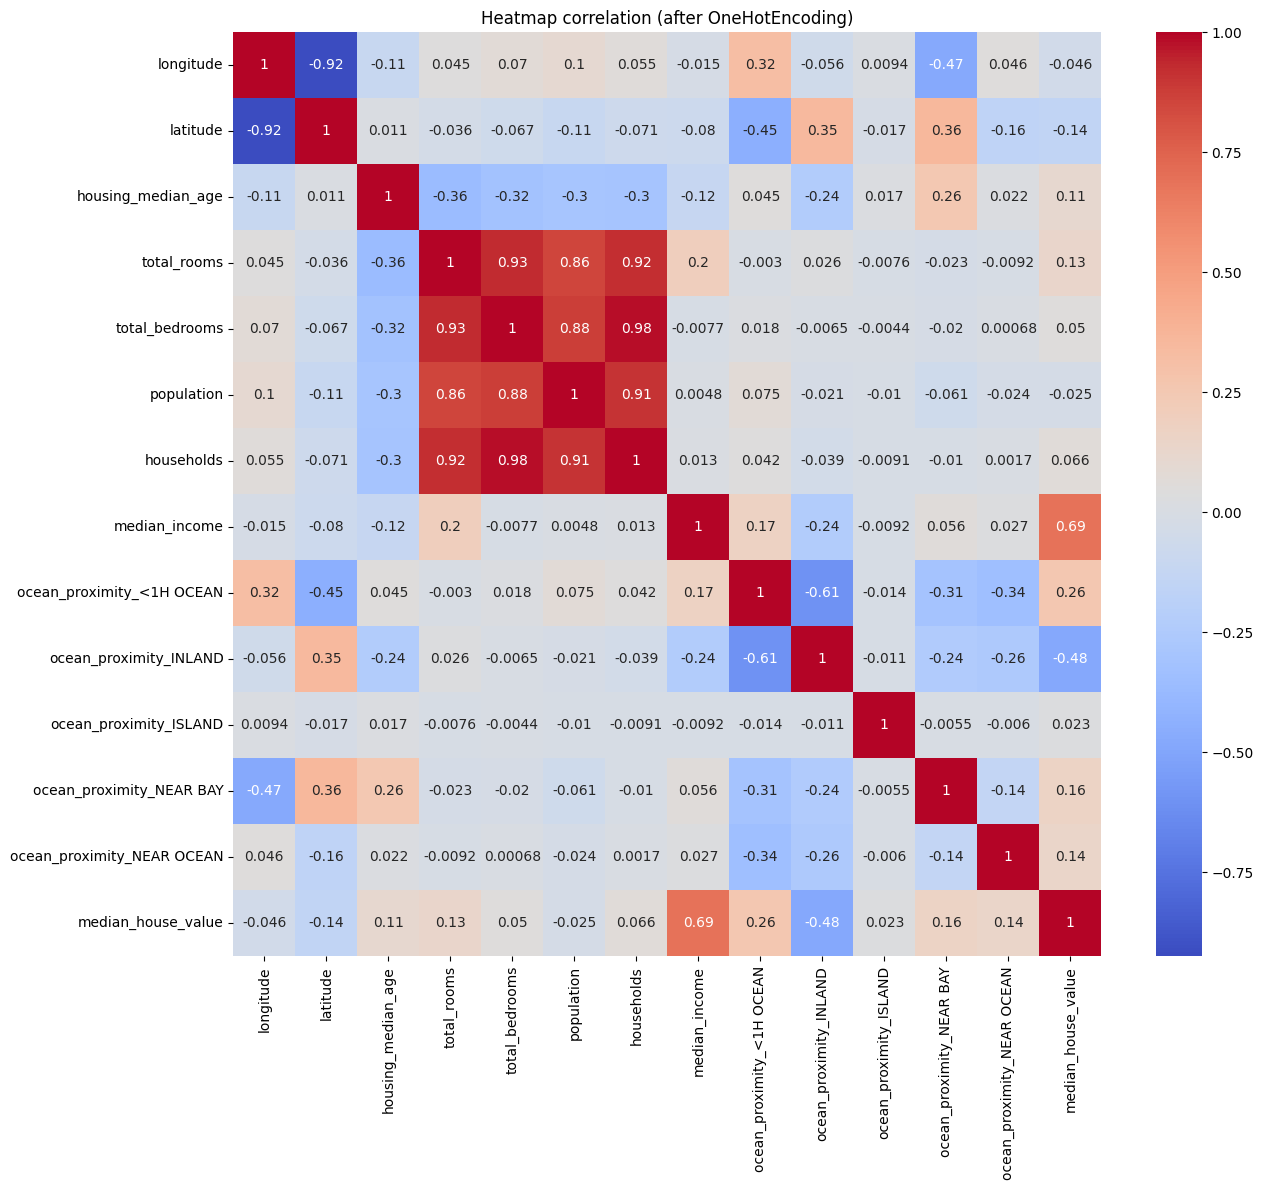

In [12]:
df1 = df.drop('median_house_value', axis=1)
df_encoded = pd.get_dummies(df1)
df_encoded['median_house_value'] = df['median_house_value']
plt.figure(figsize=(14,12))
sns.heatmap(df_encoded.corr(), cmap="coolwarm", annot=True)
plt.title("Heatmap correlation (after OneHotEncoding)")
plt.show()

# Encoding the categorical variable

In [13]:
# Now we must apply the onehot encoding for the last column "ocean proximity"
print("ocean proximity before encoding : ", np.unique(X[:, -1]))
#  Finding the number of unique values
print("number of unique values for the ocean proximity column is ",len(np.unique(X[:, 8])))

ocean proximity before encoding :  ['<1H OCEAN' 'INLAND' 'ISLAND' 'NEAR BAY' 'NEAR OCEAN']
number of unique values for the ocean proximity column is  5


## Applying the OneHotEncoding

In [14]:
# Now we gonna apply the onehot encoding
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [-1])], remainder='passthrough')
X = np.array(ct.fit_transform(X))
print("ocean proximity after encoding :")
print(X[:, :5])

ocean proximity after encoding :
[[0.0 0.0 0.0 1.0 0.0]
 [0.0 0.0 0.0 1.0 0.0]
 [0.0 0.0 0.0 1.0 0.0]
 ...
 [0.0 1.0 0.0 0.0 0.0]
 [0.0 1.0 0.0 0.0 0.0]
 [0.0 1.0 0.0 0.0 0.0]]


# Spliting the data into train and test sets

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 0)


## Feature scaling

In [16]:
from sklearn.preprocessing import StandardScaler
scX = StandardScaler()
X_train = scX.fit_transform(X_train)
X_test = scX.transform(X_test)
scY = StandardScaler()
y_train = scY.fit_transform(y_train.reshape(-1, 1))
y_test = scY.transform(y_test.reshape(-1, 1))
y_train

array([[ 2.11784529],
       [ 0.66776809],
       [ 1.84628221],
       ...,
       [ 0.17164324],
       [ 1.74357567],
       [-1.28017475]], shape=(14471, 1))

# **Models**

### In this section we gonna use all the models that we had a chance to learn during courses in class, the models are :
- Multiple Linear Regression
- Polynomiale Regression
- Support Vector Regression (SVR)
- Decision Tree Regression
- Random Forest Regression
### After Applying all this models on the dataset, We gonna evaluate all the performance off each model


In [17]:
r2Score = pd.DataFrame({
    "Model": ["Multiple Linear Regression", "Polynomial Linear Regression", "Decision Tree", "Random Forest", "SVR"],
    "R2 Score": [0, 0, 0, 0, 0]
})

## Multiple Linear Regression

In [18]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [19]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((scY.inverse_transform(y_pred.reshape(len(y_pred),1)), scY.inverse_transform(y_test.reshape(len(y_test),1))),1))

[[ 72747.35  62400.  ]
 [378944.72 418800.  ]
 [214072.01 210700.  ]
 ...
 [280364.49 246500.  ]
 [247433.35 217400.  ]
 [154340.99 132700.  ]]


In [20]:
from sklearn.metrics import r2_score
r2Score.loc[r2Score["Model"] == "Multiple Linear Regression", "R2 Score"] = r2_score(y_test, y_pred)
r2_score(y_test, y_pred)

C:\Users\sofia\AppData\Local\Temp\ipykernel_11628\1540930029.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6340448386082199' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  r2Score.loc[r2Score["Model"] == "Multiple Linear Regression", "R2 Score"] = r2_score(y_test, y_pred)


0.6340448386082199

## Polynomiale Regression

In [21]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 2)
X_poly = poly_reg.fit_transform(X_train)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y_train)

LinearRegression()

GridSearch on polynomiale regression

In [22]:
pipeline = Pipeline([
    ('poly_features', PolynomialFeatures()),
    ('regressor', LinearRegression())
])

In [38]:
param_grid = {
    'poly_features__degree': [1, 2, 3, 4],
}

In [40]:
from sklearn.model_selection import GridSearchCV
print(X_train)
best_model = GridSearchCV(pipeline, param_grid, cv=5)
best_model.fit(X_train, y_train)
print("Best parameters: ", best_model.best_params_)

[[ 1.13 -0.68 -0.01 ... -1.08 -0.87 -1.  ]
 [-0.89  1.47 -0.01 ... -0.29 -0.37  1.24]
 [-0.89 -0.68 -0.01 ... -1.   -0.88  0.46]
 ...
 [-0.89 -0.68 -0.01 ... -0.53 -0.41  0.23]
 [ 1.13 -0.68 -0.01 ... -0.78 -0.73 -0.17]
 [-0.89  1.47 -0.01 ... -0.66 -0.78 -1.18]]
Best parameters:  {'poly_features__degree': 2, 'regressor__fit_intercept': True}


In [25]:
X_test_poly = poly_reg.transform(X_test)
y_pred = lin_reg_2.predict(X_test_poly)
print(np.concatenate((scY.inverse_transform(y_pred.reshape(len(y_pred),1)), scY.inverse_transform(y_test.reshape(len(y_test),1))),1))

[[ 67840.73  62400.  ]
 [331342.59 418800.  ]
 [236387.96 210700.  ]
 ...
 [269547.   246500.  ]
 [234843.66 217400.  ]
 [131045.21 132700.  ]]


In [26]:
# from sklearn.metrics import r2_score
# r2Score.loc[r2Score["Model"] == "Polynomial Linear Regression", "R2 Score"] = r2_score(y_test, y_pred)
r2_score(y_test, y_pred)

0.5752212135788387

In [27]:
X_grid = np.arange(min(X_test.ravel()), max(X_test.ravel()), 0.1)
X_grid = X_grid.reshape(-1, 1)
print(X_test)
print(y_test)
# plt.scatter(X_test, y_test, color='red')  # données réelles
# plt.plot(X_grid, lin_reg_2.predict(poly_reg.transform(X_grid)), color='blue')  # prédiction lisse
# plt.title('Truth or Bluff (Polynomial Regression)')
# plt.xlabel('Position level')
# plt.ylabel('Salary')
# plt.show()

[[-0.89  1.47 -0.01 ... -0.29 -0.5  -1.  ]
 [-0.89  1.47 -0.01 ... -1.06 -1.09  2.79]
 [ 1.13 -0.68 -0.01 ... -0.2  -0.16  0.13]
 ...
 [ 1.13 -0.68 -0.01 ...  0.79  0.51  0.96]
 [ 1.13 -0.68 -0.01 ... -0.13 -0.46  0.5 ]
 [ 1.13 -0.68 -0.01 ...  0.38 -0.23 -0.68]]
[[-1.26]
 [ 1.85]
 [ 0.03]
 ...
 [ 0.35]
 [ 0.09]
 [-0.64]]


## Support vector machine

In [28]:
from sklearn.svm import SVR
regressorSVR = SVR(kernel = 'rbf')
regressorSVR.fit(X_train, y_train)

c:\Users\sofia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

In [29]:
y_pred = regressorSVR.predict(X_test)
print(np.concatenate((scY.inverse_transform(y_pred.reshape(len(y_pred),1)), scY.inverse_transform(y_test.reshape(len(y_test),1))),1))

[[ 53812.03  62400.  ]
 [357915.86 418800.  ]
 [189497.76 210700.  ]
 ...
 [264478.58 246500.  ]
 [206427.88 217400.  ]
 [129005.   132700.  ]]


In [30]:
from sklearn.metrics import r2_score
r2Score.loc[r2Score["Model"] == "SVR", "R2 Score"] = r2_score(y_test, y_pred)

## Decision Tree Regression

In [31]:
from sklearn.tree import DecisionTreeRegressor
regressorTree = DecisionTreeRegressor(random_state = 0)
regressorTree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=0)

In [32]:
y_pred = regressorTree.predict(X_test)
print(np.concatenate((scY.inverse_transform(y_pred.reshape(len(y_pred),1)), scY.inverse_transform(y_test.reshape(len(y_test),1))),1))

[[ 53500.  62400.]
 [475800. 418800.]
 [153100. 210700.]
 ...
 [269100. 246500.]
 [195000. 217400.]
 [105300. 132700.]]


In [33]:
from sklearn.metrics import r2_score
r2Score.loc[r2Score["Model"] == "Decision Tree", "R2 Score"] = r2_score(y_test, y_pred)

## Random Forest Regression

In [34]:
from sklearn.ensemble import RandomForestRegressor
regressorForest = RandomForestRegressor(n_estimators = 10, random_state = 0)
regressorForest.fit(X_train, y_train)

c:\Users\sofia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(n_estimators=10, random_state=0)

In [35]:
y_pred = regressorForest.predict(X_test)
print(np.concatenate((scY.inverse_transform(y_pred.reshape(len(y_pred),1)), scY.inverse_transform(y_test.reshape(len(y_test),1))),1))

[[ 61030.   62400. ]
 [478100.7 418800. ]
 [206820.  210700. ]
 ...
 [270990.  246500. ]
 [224950.  217400. ]
 [135100.  132700. ]]


In [36]:
from sklearn.metrics import r2_score
r2Score.loc[r2Score["Model"] == "Random Forest", "R2 Score"] = r2_score(y_test, y_pred)

In [37]:
r2Score.head(5)

,Model,R2 Score
0,Multiple Linear Regression,0.634045
1,Polynomial Linear Regression,0.000000
2,Decision Tree,0.664284
3,Random Forest,0.794772
4,SVR,0.753654
